In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel('ss.xls') 

In [7]:
df.head()

,Category,City,Country/Region,Customer Name,Manufacturer,Order Date,Order ID,Postal Code,Product Name,Region,Segment,Ship Date,Ship Mode,State/Province,Sub-Category,Discount,Profit,Quantity,Sales
0,Office Supplies,Houston,United States,Darren Powers,Message Book,2019-01-03,US-2019-103800,77095,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Central,Consumer,2019-01-07,Standard Class,Texas,Paper,0.2,5.5512,2,16.448
1,Office Supplies,Naperville,United States,Phillina Ober,GBC,2019-01-04,US-2019-112326,60540,GBC Standard Plastic Binding Systems Combs,Central,Home Office,2019-01-08,Standard Class,Illinois,Binders,0.8,-5.4870,2,3.540
2,Office Supplies,Naperville,United States,Phillina Ober,Avery,2019-01-04,US-2019-112326,60540,Avery 508,Central,Home Office,2019-01-08,Standard Class,Illinois,Labels,0.2,4.2717,3,11.784
3,Office Supplies,Naperville,United States,Phillina Ober,SAFCO,2019-01-04,US-2019-112326,60540,SAFCO Boltless Steel Shelving,Central,Home Office,2019-01-08,Standard Class,Illinois,Storage,0.2,-64.7748,3,272.736
4,Office Supplies,Philadelphia,United States,Mick Brown,Avery,2019-01-05,US-2019-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,East,Consumer,2019-01-12,Standard Class,Pennsylvania,Art,0.2,4.8840,3,19.536


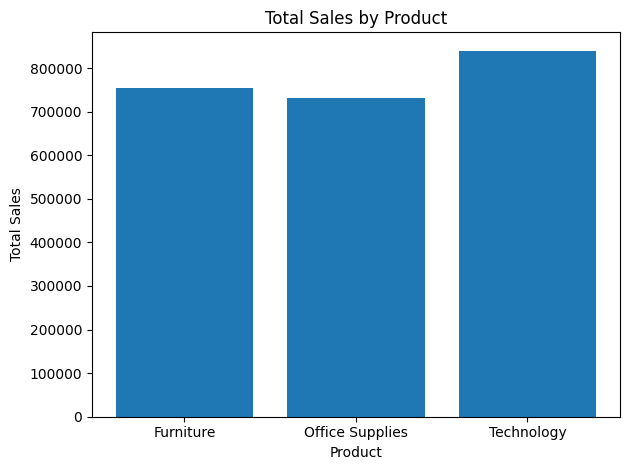

In [18]:
sales = df.groupby('Category')['Sales'].sum()
plt.figure()
plt.bar(sales.index, sales.values)
plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')
# 
plt.tight_layout()
plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        10194 non-null  object        
 1   City            10194 non-null  object        
 2   Country/Region  10194 non-null  object        
 3   Customer Name   10194 non-null  object        
 4   Manufacturer    10194 non-null  object        
 5   Order Date      10194 non-null  datetime64[ns]
 6   Order ID        10194 non-null  object        
 7   Postal Code     10194 non-null  object        
 8   Product Name    10194 non-null  object        
 9   Region          10194 non-null  object        
 10  Segment         10194 non-null  object        
 11  Ship Date       10194 non-null  datetime64[ns]
 12  Ship Mode       10194 non-null  object        
 13  State/Province  10194 non-null  object        
 14  Sub-Category    10194 non-null  object        
 15  Di

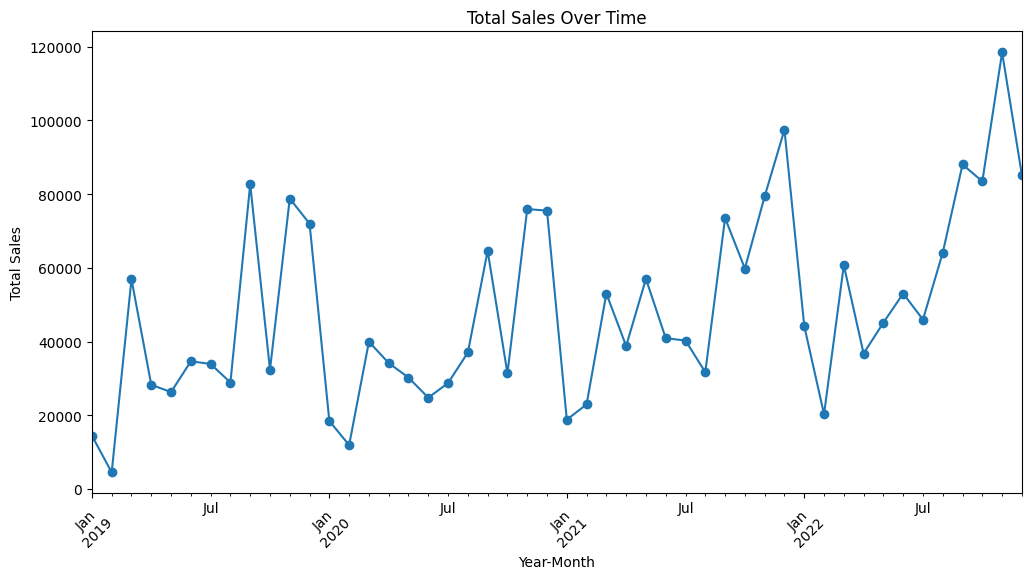

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Load dataset

df = pd.read_excel("ss.xls" )
print(df.info())








 #Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
 #1. Sales Trends Over Time
#How do total sales vary over different months and years? 
df['Year-Month'] = df['Order Date'].dt.to_period('M')
'''Parameter	Description	Example Output
'Y'	Yearly	2023
'M'	Monthly	2023-01
'Q'	Quarterly	2023Q1
'W'	Weekly	2023-05-14 (Week starting)
'D'	Daily	2023-05-14
'H'	Hourly	2023-05-14 15:00
'T' or 'min'	Minute	2023-05-14 15:30'''
salestrend = df.groupby('Year-Month')['Sales'].sum()
plt.figure(figsize=(12, 6))
salestrend.plot(marker='o')
plt.title('Total Sales Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()



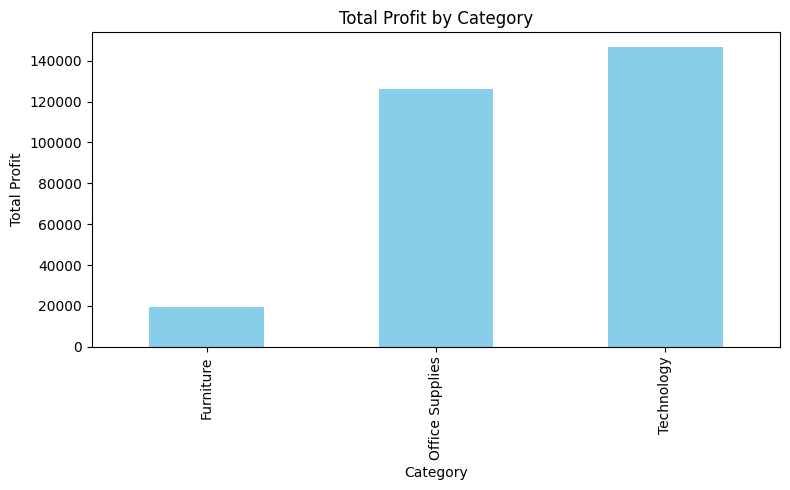

In [30]:
#2. Most Profitable Categories
#Which product categories generate the highest profit?
plt.figure(figsize=(8, 5))
categoryprofit = df.groupby('Category')['Profit'].sum().sort_values()
categoryprofit.plot(kind='bar', color='skyblue')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

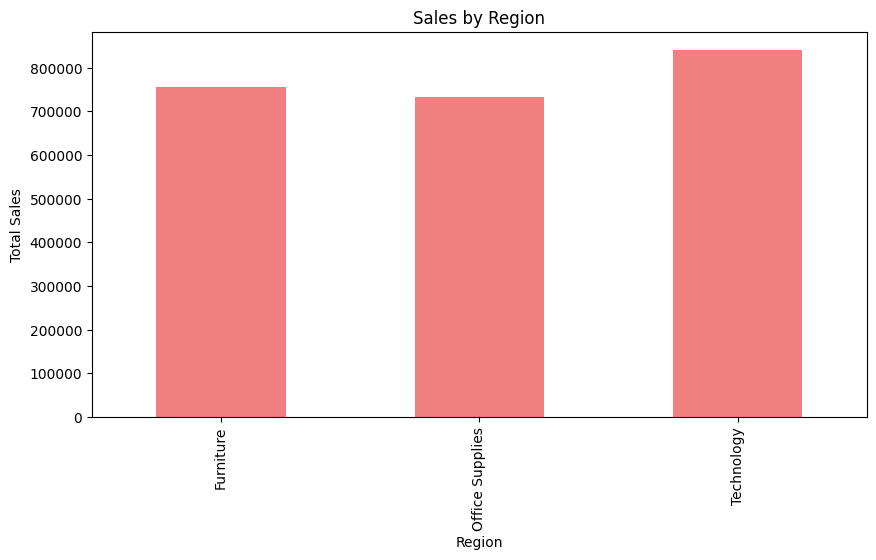

In [33]:
# 3. Regional Performance
#Which regions contribute the most to sales and profit?
plt.figure(figsize=(10, 5))
regionsales = df.groupby('Region')['Sales'].sum().sort_values()

sales.plot(kind='bar', color='lightcoral')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show() 

Text(0, 0.5, '')

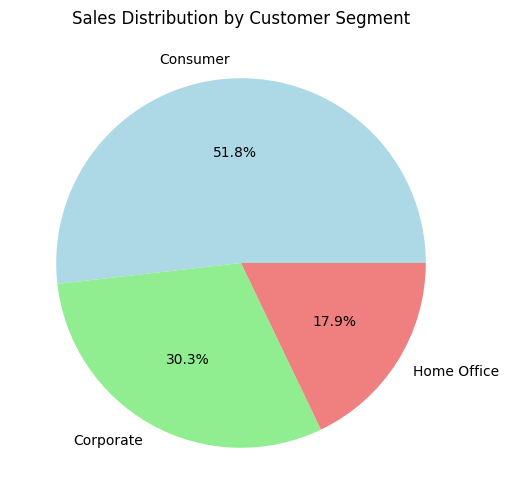

In [34]:
# 4. Customer Segments Analysis
#How do different customer segments (Consumer, Home Office, Corporate) contribute to sales and profit?
plt.figure(figsize=(6, 6))
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Sales Distribution by Customer Segment')
plt.ylabel('')

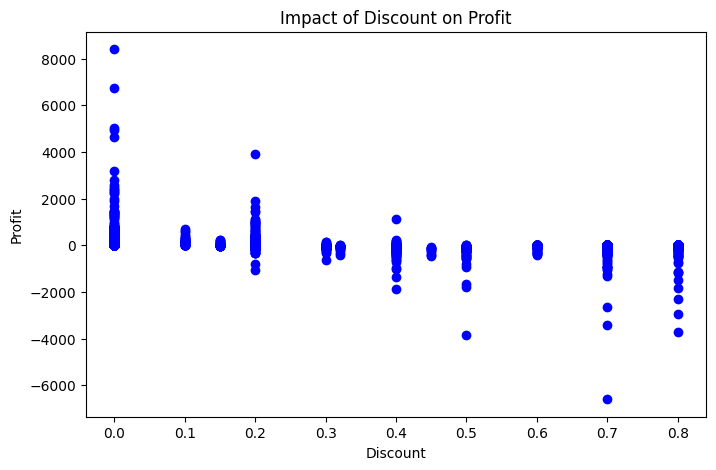

In [35]:
#5. Impact of Discounts on Profitability
#How does increasing the discount percentage affect profitability? 
plt.figure(figsize=(8, 5))
plt.scatter(df.Discount,df.Profit,color="blue",marker='o')
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()


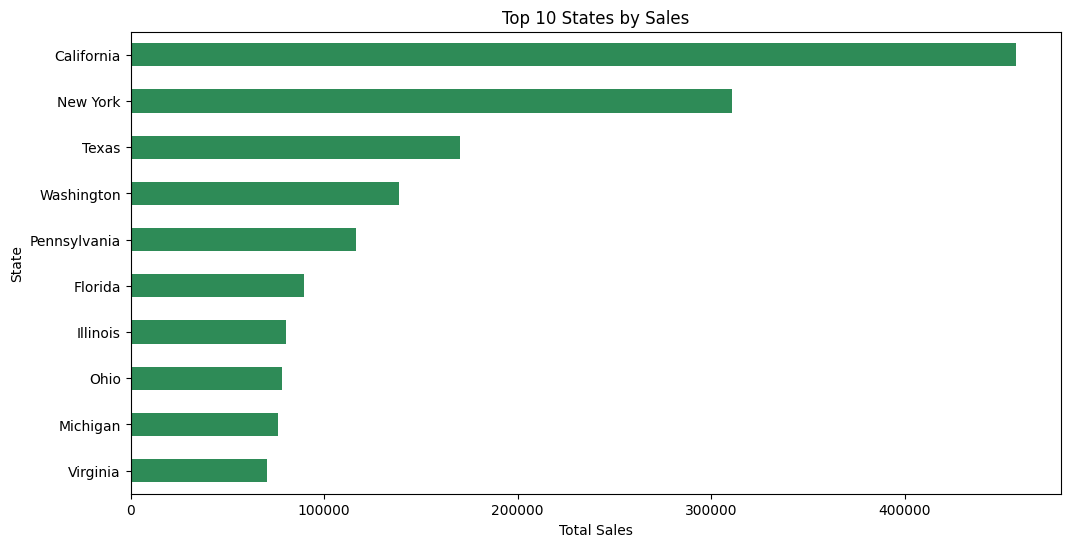

In [37]:
# 6. Best and Worst Performing States
#Which states have the highest and lowest total sales?
plt.figure(figsize=(12, 6))
statesales = df.groupby('State/Province')['Sales'].sum().sort_values()
statesales[-10:].plot(kind='barh', color='seagreen')
plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.show()


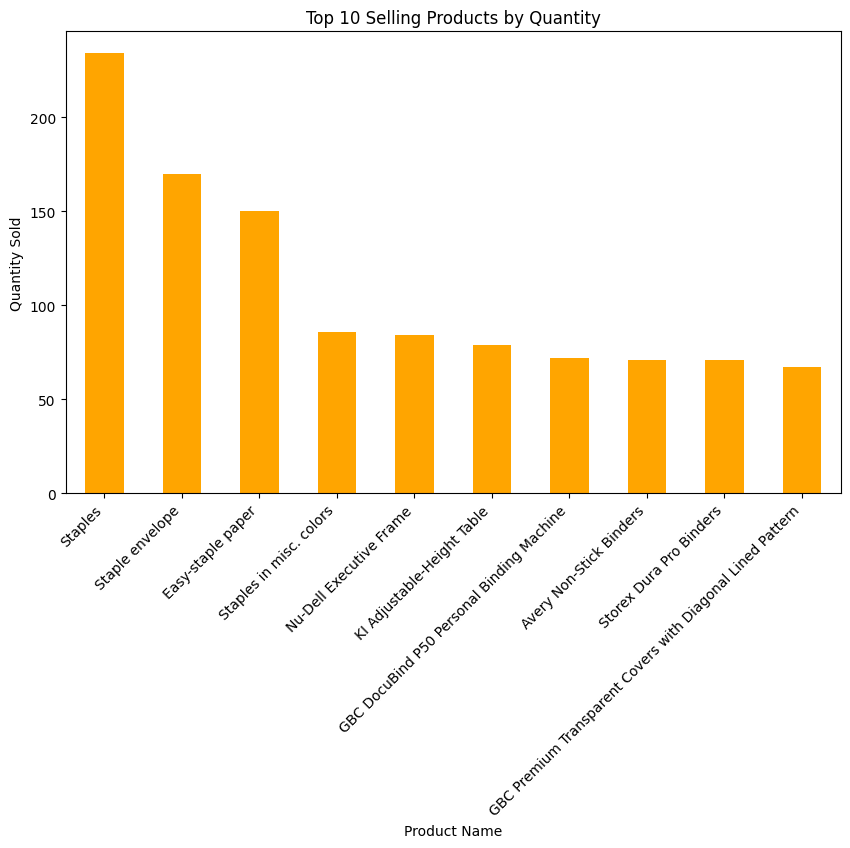

In [38]:
# 7. Top Selling Products
#What are the top 10 most sold products in terms of quantity? 
topproducts = df.groupby('Product Name')['Quantity'].sum().nlargest(10)
plt.figure(figsize=(10, 6))
topproducts.plot(kind='bar', color='orange')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Product Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.show()

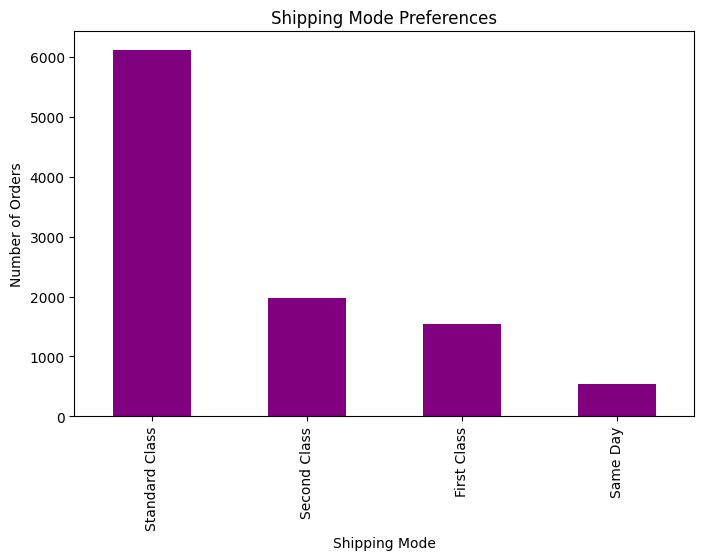

In [39]:
# 8. Shipping Mode Preferences
#What are the most commonly used shipping modes, and how do they impact sales and delivery time? 
plt.figure(figsize=(8, 5))
df['Ship Mode'].value_counts().plot(kind='bar', color='purple')
plt.title('Shipping Mode Preferences')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.show()

Text(0, 0.5, 'Number of Customers')

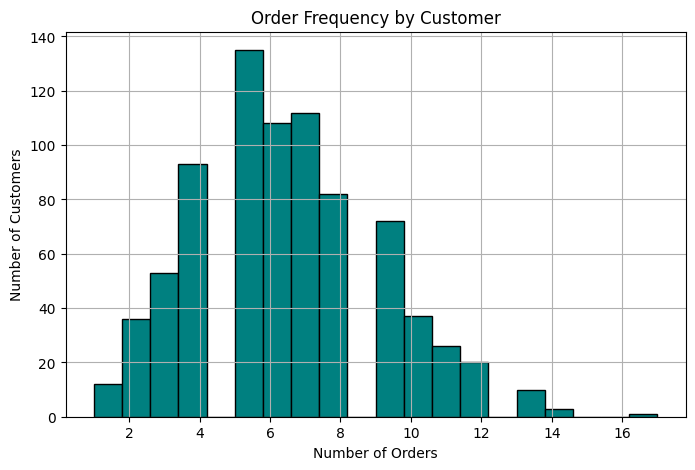

In [40]:
# 9. Order Frequency by Customer
#How many customers place multiple orders, and what percentage of orders come from repeat customers?
customerorders = df.groupby('Customer Name')['Order ID'].nunique()
plt.figure(figsize=(8, 5))
customerorders.hist(bins=20, color='teal', edgecolor='black')
plt.title('Order Frequency by Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

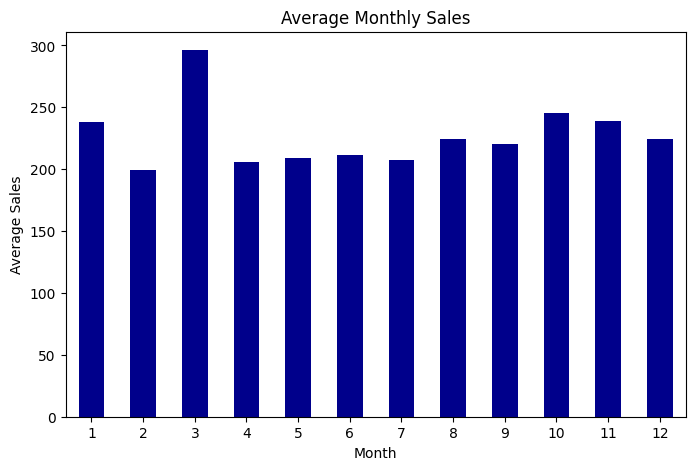

In [42]:
# 10. Seasonality in Sales
#Are there certain months where sales peak, indicating seasonality?
df['Month'] = df['Order Date'].dt.month
monthlysales = df.groupby('Month')['Sales'].mean()
plt.figure(figsize=(8, 5))
monthlysales.plot(kind='bar', color='darkblue')
plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()